# POD11 SSI — Reproduction + Image-Degradation Robustness (Colab)

**What this notebook does, in order:**
1. Stage data and preprocess (POD11-preferred / POD10 fallback).
2. **Generate results** via 5-fold cross-validation on the full cohort.
3. In the **same** cross-validation, score each held-out fold both clean and under
   every degradation level, so every image is degraded-tested exactly once.
4. Freeze the operating threshold on clean out-of-fold predictions.
5. Pool the out-of-fold predictions and report **AUC-retention curves** with
   bootstrap 95% CIs.
6. (Optional) Train one final model on all data as a deployable artifact.

**Why it's built this way.**Instead the degradation is measured *through* the
5-fold cross-validation: each fold trains on 4/5 of the **full-quality** images and
is scored on its held-out 1/5 both clean and degraded. Rotating through all folds,
every image — all ~44 infected — contributes one honest degraded prediction from a
model that never trained on it. Report **AUC-based retention** as the headline
(threshold-free); treat sensitivity/specificity as supporting.

## 0. Setup — install deps, check GPU

In [ ]:
# Pin albumentations to a version whose transform API matches the training pipeline.
# If Colab asks to restart the runtime after install, click "Restart", then run all cells again.
!pip install -q albumentations==1.3.1

import torch
print('CUDA available:', torch.cuda.is_available(),
      '| GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (will be slow)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.7 MB/s eta 0:00:00
CUDA available: True | GPU: Tesla T4


## 1. Imports & config

In [ ]:
import os, glob, re, cv2, numpy as np, pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import torchvision.models as models
import matplotlib.pyplot as plt

torch.manual_seed(42); np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Manuscript-canonical config ----
CFG = dict(
    img_size     = 224,
    n_folds      = 5,
    max_epochs   = 50,      # manuscript
    lr           = 1e-4,    # manuscript
    weight_decay = 1e-4,    # manuscript
    patience     = 5,       # manuscript early-stopping
    pos_weight   = 15.0,    # manuscript: 15x weight on infected
    threshold    = 0.42,    # manuscript Table 1 (POD11 row) — used unless overridden below
    batch_size   = 16,
    num_workers  = 2,
    seed         = 42,
)

## 2. Mount Drive and stage files into Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, zipfile

found = {}
for root, _, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f == 'Telemed_SSI_AMR_variables.csv' and 'csv' not in found:
            found['csv'] = os.path.join(root, f)
        elif f == 'files.zip' and 'zip' not in found:
            found['zip'] = os.path.join(root, f)

print('Found:')
for k, v in found.items():
    print(f'  {k}: {v}')

assert 'csv' in found, 'Telemed_SSI_AMR_variables.csv not found in Drive.'
shutil.copy(found['csv'], '/content/Telemed_SSI_AMR_variables.csv')

if not os.path.exists('/content/files'):
    assert 'zip' in found, 'files.zip not found in Drive.'
    print('Unzipping files.zip (this takes a few minutes)...')
    with zipfile.ZipFile(found['zip']) as z:
        z.extractall('/content/')
    print('Unzipped.')

print('\nFiles staged. Ready to run.')

Mounted at /content/drive
Found:
  zip: /content/drive/MyDrive/Krisha SSI images  code/files.zip
  csv: /content/drive/MyDrive/Krisha SSI images  code/Telemed_SSI_AMR_variables.csv
Unzipping files.zip (this takes a few minutes)...
Unzipped.

Files staged. Ready to run.


## 3. Resolve paths + preprocessing (POD11-preferred / POD10 fallback)
`CSV_PATH` is the staged CSV; raw images live under `/content/files`. The blur
filter is intentionally **off** so no images are dropped before the degradation study.

In [ ]:
CSV_PATH = '/content/Telemed_SSI_AMR_variables.csv'
OUT_DIR  = '/content/processed'
IMG_EXTS = ('.jpg', '.jpeg', '.png')

def imgs_under(root):
    paths = glob.glob(os.path.join(root, '**', '*'), recursive=True)
    return [p for p in paths if p.lower().endswith(IMG_EXTS) and os.path.isfile(p)]

RAW_DIR = '/content/files'
assert os.path.isdir(RAW_DIR), f'{RAW_DIR} not found. Check that files.zip unpacked correctly.'
assert os.path.isfile(CSV_PATH), f'CSV not found: {CSV_PATH}'
_imgs = imgs_under(RAW_DIR)
assert _imgs, f'No images ({IMG_EXTS}) found under {RAW_DIR}.'
print('CSV_PATH:', CSV_PATH)
print('RAW_DIR :', RAW_DIR, f'({len(_imgs)} images)')
print('Samples :', [os.path.basename(p) for p in _imgs[:5]])


class Preprocessor:
    @staticmethod
    def to_binary(v):
        if pd.isna(v): return None
        s = str(v).strip().lower()
        if s in ('1','1.0','yes','y','true','t','positive','pos','infected','ssi'):   return 1
        if s in ('0','0.0','no','n','false','f','negative','neg','uninfected','none'): return 0
        try:
            return 1 if float(s) >= 0.5 else 0
        except ValueError:
            return None

    @staticmethod
    def pick_for_record(imgs, rec_id, pod_encoded):
        if pod_encoded:
            p11 = [p for p in imgs if f'visible-{rec_id}-p11-' in os.path.basename(p)]
            if p11: return p11[0]
            p10 = [p for p in imgs if f'visible-{rec_id}-p10-' in os.path.basename(p)]
            return p10[0] if p10 else None
        cand = [p for p in imgs
                if re.match(rf'0*{rec_id}\b', os.path.splitext(os.path.basename(p))[0])]
        return cand[0] if cand else None

    @staticmethod
    def preprocess(raw_dir=RAW_DIR, csv_path=CSV_PATH, out_dir=OUT_DIR):
        df = pd.read_csv(csv_path)
        for lbl in ['infected', 'uninfected']:
            os.makedirs(os.path.join(out_dir, lbl), exist_ok=True)
        imgs = imgs_under(raw_dir)
        pod_encoded = any(re.search(r'visible-\d+-p1[01]-', os.path.basename(p)) for p in imgs)
        print(f'{len(imgs)} images under RAW_DIR | POD-encoded filenames: {pod_encoded}')

        kept = skipped_lbl = 0
        for rec_id in sorted(df['record_id'].dropna().unique()):
            rec_id = int(rec_id)
            path = Preprocessor.pick_for_record(imgs, rec_id, pod_encoded)
            if path is None: continue
            img = cv2.imread(path)
            if img is None: continue
            img = cv2.resize(img, (CFG['img_size'],)*2, interpolation=cv2.INTER_AREA)
            row = df[df['record_id'] == rec_id]
            if len(row) == 0: continue
            ssi = Preprocessor.to_binary(row['ssi'].iloc[0])
            if ssi is None:
                skipped_lbl += 1; continue
            lbl = 'infected' if ssi == 1 else 'uninfected'
            cv2.imwrite(os.path.join(out_dir, lbl, f'{rec_id}.jpg'), img)
            kept += 1
        if skipped_lbl:
            print(f'(skipped {skipped_lbl} records with blank/unrecognized ssi labels)')
        assert kept > 0, 'Preprocessing kept 0 images — filename convention likely differs.'
        print(f'Preprocessed {kept} images -> {out_dir}')

Preprocessor.preprocess()

CSV_PATH: /content/Telemed_SSI_AMR_variables.csv
RAW_DIR : /content/files (4452 images)
Samples : ['color-649-p10-2020.02.03.09.42.40.jpg', 'color-649-p3-2020.01.30.11.54.20.jpg', 'visible-649-p3-2020.01.30.11.54.20.jpg', 'visible-649-p11-2020.02.04.09.55.05.jpg', 'visible-649-p10-2020.02.03.09.42.40.jpg']
4452 images under RAW_DIR | POD-encoded filenames: True
(skipped 19 records with blank/unrecognized ssi labels)
Preprocessed 766 images -> /content/processed


## 4. Load the full cohort

In [ ]:
inf   = sorted(glob.glob(os.path.join(OUT_DIR,'infected','*.jpg')))
uninf = sorted(glob.glob(os.path.join(OUT_DIR,'uninfected','*.jpg')))
all_paths  = inf + uninf
all_labels = np.array([1]*len(inf) + [0]*len(uninf))
assert len(all_paths) > 0, 'No processed images found — check section 3.'
print(f'Total {len(all_paths)} images  (infected={len(inf)}, uninfected={len(uninf)})')

Total 766 images  (infected=44, uninfected=722)


## 5. Augmentation, dataset, loader

In [ ]:
NORM = A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
train_augs = A.Compose([
    A.RandomResizedCrop(CFG['img_size'], CFG['img_size'], scale=(0.8,1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
    NORM, ToTensorV2()])
eval_augs = A.Compose([A.CenterCrop(CFG['img_size'], CFG['img_size']), NORM, ToTensorV2()])

class WoundDataset(Dataset):
    def __init__(self, paths, labels, augs):
        self.paths, self.labels, self.augs = paths, labels, augs
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.paths[idx]), cv2.COLOR_BGR2RGB)
        x = self.augs(image=img)['image']
        return x, torch.tensor(self.labels[idx], dtype=torch.float32)

def make_loader(paths, labels, augs, train):
    labels = list(labels)
    ds = WoundDataset(paths, labels, augs)
    if train:
        counts = np.bincount([int(l) for l in labels], minlength=2)
        w = 1.0 / np.clip(counts, 1, None)
        sw = [w[int(l)] for l in labels]
        sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
        return DataLoader(ds, batch_size=CFG['batch_size'], sampler=sampler, num_workers=CFG['num_workers'])
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


## 6. Model + training loop (fine-tuned ResNet50)

In [ ]:
def build_resnet():
    try:
        net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    except Exception:
        net = models.resnet50(pretrained=True)
    net.fc = nn.Linear(net.fc.in_features, 1)   # single binary output
    return net

@torch.no_grad()
def predict(model, loader):
    model.eval()
    ps, ys = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE)).squeeze(1)
        ps.append(torch.sigmoid(logits).cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ps), np.concatenate(ys)

def train_model(train_loader, val_loader=None, verbose=False):
    model = build_resnet().to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    crit  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(CFG['pos_weight'], device=DEVICE))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    best_auc, best_state, wait = -1.0, None, 0
    for epoch in range(CFG['max_epochs']):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x).squeeze(1), y)
            loss.backward(); opt.step()
        if val_loader is not None:
            p, t = predict(model, val_loader)
            auc = roc_auc_score(t, p) if len(set(t)) > 1 else 0.0
            sched.step(auc)
            if verbose: print(f'  epoch {epoch+1:02d}  val_auc={auc:.3f}')
            if auc > best_auc:
                best_auc = auc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= CFG['patience']: break
    if best_state is not None:
        model.load_state_dict(best_state)   # restore best-AUC weights
    return model, best_auc

In [ ]:
# =============================================================================
# Corruption grid — defined HERE (before the CV loop in Section 8) so each
# held-out fold can be scored clean AND degraded inside the cross-validation.
# ImageNet-C-style corruptions at a fixed grid of severities, applied BEFORE the
# normal eval preprocessing, so the only difference from clean is the corruption.
# Transforms are deterministic (p=1.0, min==max ranges).  (Plan 2.8 units.)
# 21 levels so every axis contains its own unchanged level exactly.
# =============================================================================
BLUR_SIGMAS      = np.linspace(0.0, 15.0, 21)   # sigma 0 -> 15, step 0.75
BRIGHT_FACTORS   = np.linspace(0.2, 1.8, 21)    # 1.0 is level 10, dead centre
CONTRAST_FACTORS = np.linspace(0.2, 1.8, 21)

assert 0.0 in BLUR_SIGMAS and 1.0 in BRIGHT_FACTORS and 1.0 in CONTRAST_FACTORS, \
    "each grid must contain its unchanged level"

def apply_blur(img, sigma):
    if sigma <= 0:                               # sigma=0 is a no-op (== baseline)
        return img
    return cv2.GaussianBlur(img, (0, 0), sigmaX=float(sigma), sigmaY=float(sigma))

def apply_brightness(img, factor):               # <1 darker, 1.0 unchanged, >1 brighter
    return np.clip(np.rint(img.astype(np.float32) * float(factor)), 0, 255).astype(np.uint8)

def apply_contrast(img, factor):
    """Scale pixels around each image's own mean, so the contrast axis doesn't
    double as a brightness axis. factor=1.0 -> unchanged."""
    f = img.astype(np.float32)
    pivot = f.mean(axis=(0, 1), keepdims=True)   # per-channel mean
    return np.clip(np.rint((f - pivot) * float(factor) + pivot), 0, 255).astype(np.uint8)

def deg_pipeline(op, value):
    """Apply one exact degradation, then the same CenterCrop/NORM/ToTensor as eval."""
    def _fn(image, **kw):
        return op(image, value)
    return A.Compose([
        A.Lambda(image=_fn),
        A.CenterCrop(CFG['img_size'], CFG['img_size']),
        NORM, ToTensorV2(),
    ])

DEGRADATIONS = {
    "blur":       (apply_blur,       BLUR_SIGMAS),
    "brightness": (apply_brightness, BRIGHT_FACTORS),
    "contrast":   (apply_contrast,   CONTRAST_FACTORS),
}
print("Degradation grid: 3 types x 21 levels =",
      sum(len(v) for _, v in DEGRADATIONS.values()), "levels (+ 1 clean baseline)")

Degradation grid: 3 types x 21 levels = 63 levels (+ 1 clean baseline)


## 7. No separate held-out split — the CV folds ARE the held-out sets
Earlier versions carved off a single 15% test set for the degradation study, which
left only ~6–7 infected images to measure on (hence very wide CIs). That step is
gone. Instead the whole cohort goes into the 5-fold cross-validation below: each
fold's held-out 1/5 is the "test set" for that iteration, scored **both clean and
degraded**, so every image is degraded-tested exactly once by a model that never
trained on it — pooling to all ~44 infected cases.

## 8. 5-fold cross-validation — reproduction AND degradation in one loop
Every case gets exactly one out-of-fold prediction from a model that did not train
on it. In the **same** loop we also score each held-out fold under every degradation
level and store the results for Section 12. First confirm the pooled/mean AUC matches
Krisha's reported value before trusting anything downstream.

In [ ]:
import os
for f in ['oof_clean.npy', 'oof_deg.npz', 'fold_aucs.npy']:
    p = os.path.join('/content/pod11_final', f)
    if os.path.exists(p):
        os.remove(p); print('removed', p)
print('cache cleared — next Section 8 run will train fresh and freeze that run')

cache cleared — next Section 8 run will train fresh and freeze that run


In [ ]:
import os, numpy as np

# Point this at a Google Drive path if you want the freeze to survive Colab
# runtime resets — /content is wiped when the runtime recycles.
OOF_DIR        = '/content/drive/MyDrive/pod11_final'
OOF_CLEAN_PATH = os.path.join(OOF_DIR, 'oof_clean.npy')
OOF_DEG_PATH   = os.path.join(OOF_DIR, 'oof_deg.npz')
FOLD_AUC_PATH  = os.path.join(OOF_DIR, 'fold_aucs.npy')
os.makedirs(OOF_DIR, exist_ok=True)

_have_cache = all(os.path.exists(p) for p in (OOF_CLEAN_PATH, OOF_DEG_PATH, FOLD_AUC_PATH))

if _have_cache:
    print('Cached OOF predictions found — loading them and SKIPPING training.')
    print('(Delete the .npy/.npz files in OOF_DIR to force a fresh retrain.)')
    oof_clean = np.load(OOF_CLEAN_PATH)
    fold_aucs = list(np.load(FOLD_AUC_PATH))
    _npz = np.load(OOF_DEG_PATH)
    oof_deg = {name: [_npz[name][i] for i in range(len(values))]
               for name, (op, values) in DEGRADATIONS.items()}

else:
    print('No cache — training the five folds ONCE, then saving OOF predictions.\n')
    skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

    N = len(all_paths)
    oof_clean = np.full(N, np.nan)                     # clean held-out prediction per image
    oof_deg   = {name: [np.full(N, np.nan) for _ in values]   # one array per (degradation, level)
                 for name, (op, values) in DEGRADATIONS.items()}
    fold_aucs = []

    for fold, (tr, va) in enumerate(skf.split(all_paths, all_labels)):
        tr_p = [all_paths[i] for i in tr]; tr_l = all_labels[tr]
        va_p = [all_paths[i] for i in va]; va_l = all_labels[va]

        # Train on the 4 training folds using CLEAN (full-quality) images.
        tr_loader = make_loader(tr_p, tr_l, train_augs, train=True)
        va_loader = make_loader(va_p, va_l, eval_augs,  train=False)
        model, _  = train_model(tr_loader, va_loader)   # restores best-AUC weights
        torch.save(model.state_dict(),
                   os.path.join(OOF_DIR, f'fold{fold+1}_weights.pt'))

        # Clean predictions on the held-out fold.
        p, _ = predict(model, va_loader)
        oof_clean[va] = p
        fa = roc_auc_score(va_l, p) if len(set(va_l)) > 1 else float('nan')
        fold_aucs.append(fa)
        print(f"Fold {fold+1}: clean val AUC = {fa:.3f}")

        # Degraded predictions on the SAME held-out fold, every level.
        for name, (op, values) in DEGRADATIONS.items():
            for i, v in enumerate(values):
                dloader = make_loader(va_p, va_l, deg_pipeline(op, v), train=False)
                dp, _ = predict(model, dloader)
                oof_deg[name][i][va] = dp
        n_levels = sum(len(v) for _, v in DEGRADATIONS.values())
        print(f"  fold {fold+1}: degraded inference done ({n_levels} levels)")

    assert not np.isnan(oof_clean).any(), "Some case never got an OOF clean prediction."

    # ---- FREEZE: save once so every later number is reproducible ----
    np.save(OOF_CLEAN_PATH, oof_clean)
    np.save(FOLD_AUC_PATH, np.array(fold_aucs))
    np.savez(OOF_DEG_PATH, **{name: np.stack(oof_deg[name]) for name in oof_deg})
    print(f'\nSaved OOF predictions to {OOF_DIR} — future runs will reload these.')

# ---- Everything below is a pure function of the arrays above (deterministic) ----
oof_probs = oof_clean                              # keep the old name so Section 9 still works

pooled_auc = roc_auc_score(all_labels, oof_clean)
mean_auc   = float(np.nanmean(fold_aucs))
q1, q3     = np.nanpercentile(fold_aucs, [25, 75])
print(f"\nMean fold AUC  = {mean_auc:.3f}  (IQR {q1:.3f}-{q3:.3f})")
print(f"Pooled OOF AUC = {pooled_auc:.3f}  (all {N if not _have_cache else len(all_paths)} images, {int(all_labels.sum())} infected)")
print("  -> compare against Krisha's reported AUC to confirm the pipeline matches.")

Cached OOF predictions found — loading them and SKIPPING training.
(Delete the .npy/.npz files in OOF_DIR to force a fresh retrain.)

Mean fold AUC  = 0.876  (IQR 0.822-0.924)
Pooled OOF AUC = 0.827  (all 766 images, 44 infected)
  -> compare against Krisha's reported AUC to confirm the pipeline matches.


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# Clean pooled out-of-fold results from Section 8
y_true = np.asarray(all_labels)
y_prob = np.asarray(oof_probs)

target_sens = 0.80
target_spec = 0.70

# Generate all possible ROC operating points
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
specificity = 1 - fpr

# Thresholds meeting BOTH minimum requirements
valid = np.where(
    (tpr >= target_sens) &
    (specificity >= target_spec) &
    np.isfinite(thresholds)
)[0]

if len(valid) > 0:
    # Among acceptable thresholds, choose the point closest
    # to exactly 80% sensitivity and 70% specificity
    distance = (
        (tpr[valid] - target_sens) ** 2 +
        (specificity[valid] - target_spec) ** 2
    )

    best_idx = valid[np.argmin(distance)]

    status = "Both targets achieved."

else:
    # If both cannot be achieved, preserve >=80% sensitivity
    # and choose the threshold with the highest specificity
    sens_valid = np.where(
        (tpr >= target_sens) &
        np.isfinite(thresholds)
    )[0]

    if len(sens_valid) == 0:
        raise ValueError(
            "No threshold achieves at least 80% sensitivity."
        )

    best_idx = sens_valid[
        np.argmax(specificity[sens_valid])
    ]

    status = (
        "Warning: no threshold achieved both targets. "
        "Selected the highest specificity available while "
        "maintaining at least 80% sensitivity."
    )

FIXED_THRESHOLD = float(thresholds[best_idx])
CFG["threshold"] = FIXED_THRESHOLD

# Confirm the selected operating point directly
pred = (y_prob >= FIXED_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(
    y_true,
    pred,
    labels=[0, 1]
).ravel()

sensitivity = tp / (tp + fn)
specificity_selected = tn / (tn + fp)

print(status)
print(f"Frozen clean OOF threshold = {FIXED_THRESHOLD:.6f}")
print(f"Sensitivity               = {sensitivity:.3f}")
print(f"Specificity               = {specificity_selected:.3f}")
print(f"Confusion matrix           = [[{tn}, {fp}], [{fn}, {tp}]]")

Both targets achieved.
Frozen clean OOF threshold = 0.366158
Sensitivity               = 0.818
Specificity               = 0.713
Confusion matrix           = [[515, 207], [8, 36]]


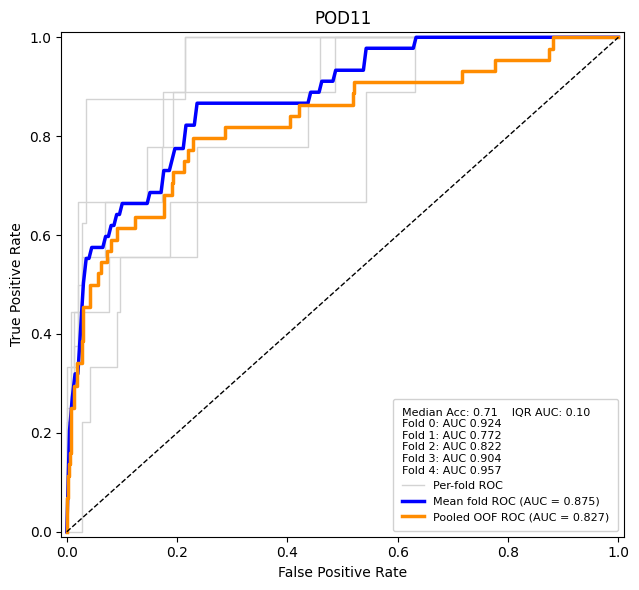

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score
import numpy as np, os
import matplotlib.pyplot as plt

ACC_THRESHOLD = FIXED_THRESHOLD   # accuracy at your operating point

# Rebuild the SAME fold splits used in Section 8 (deterministic)
skf_plot = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True,
                           random_state=CFG['seed'])

mean_fpr = np.linspace(0, 1, 200)
tprs, fold_auc_list, fold_acc_list = [], [], []

fig, ax = plt.subplots(figsize=(6.5, 6))

for k, (_, va) in enumerate(skf_plot.split(all_paths, all_labels)):
    y_true = all_labels[va]
    y_prob = oof_probs[va]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fold_auc_list.append(auc(fpr, tpr))
    fold_acc_list.append(accuracy_score(y_true, (y_prob >= ACC_THRESHOLD).astype(int)))
    it = np.interp(mean_fpr, fpr, tpr); it[0] = 0.0
    tprs.append(it)
    ax.plot(fpr, tpr, color='lightgrey', lw=1,
            label='Per-fold ROC' if k == 0 else None)   # only ONE grey legend entry

# Mean fold ROC
mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, color='blue', lw=2.5,
        label=f'Mean fold ROC (AUC = {mean_auc:.3f})')

# Pooled OOF ROC
pooled_fpr, pooled_tpr, _ = roc_curve(all_labels, oof_probs)
pooled_auc = auc(pooled_fpr, pooled_tpr)
ax.plot(pooled_fpr, pooled_tpr, color='darkorange', lw=2.5,
        label=f'Pooled OOF ROC (AUC = {pooled_auc:.3f})')

# Chance line
ax.plot([0, 1], [0, 1], ls='--', color='black', lw=1)

# ---- Summary stats go in the legend TITLE, so there is only ONE box ----
q1, q3 = np.percentile(fold_auc_list, [25, 75])
title_lines  = [f'Median Acc: {np.median(fold_acc_list):.2f}    IQR AUC: {q3 - q1:.2f}']
title_lines += [f'Fold {i}: AUC {a:.3f}' for i, a in enumerate(fold_auc_list)]

leg = ax.legend(loc='lower right', fontsize=8,
                title='\n'.join(title_lines), title_fontsize=8,
                framealpha=0.9, borderpad=0.8)
leg._legend_box.align = "left"   # left-align the title block

ax.set_title('POD11')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
fig.tight_layout()

os.makedirs('/content/pod11_final', exist_ok=True)
fig.savefig('/content/pod11_final/pod11_roc_reproduction.png', dpi=300)
plt.show()

## 9. Freeze the operating threshold
Chosen **once**, on unseen out-of-fold predictions, then reused for every
corruption. Never re-pick a threshold on the final model's own training data.

## 10. Train one final model on all data
This trains a single model on the entire cohort and saves the weights. It is the
deployable artifact; the **degradation analysis does NOT use it** (that runs on the
out-of-fold fold models from Section 8). Skip this cell if you only need the
robustness results.

In [ ]:
full_loader = make_loader(all_paths, all_labels, train_augs, train=True)
final_model, _ = train_model(full_loader, val_loader=None)   # fixed max_epochs
print("Final model trained on the full cohort (deployable artifact).")

# save weights
import json
os.makedirs('/content/pod11_final', exist_ok=True)
torch.save(final_model.state_dict(), '/content/pod11_final/pod11_final_model.pt')
with open('/content/pod11_final/meta.json', 'w') as f:
    json.dump({
        "note": "Final model trained on the full cohort. The degradation analysis uses "
                "the out-of-fold fold models from Section 8, NOT this artifact.",
        "n_total": len(all_paths),
        "frozen_threshold": FIXED_THRESHOLD,
        "reproduction_mean_auc": mean_auc, "reproduction_pooled_auc": pooled_auc,
    }, f, indent=2)
print("Saved final model + metadata to /content/pod11_final/")

Final model trained on the full cohort (deployable artifact).
Saved final model + metadata to /content/pod11_final/


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def select_threshold(y_true, y_prob, target_sens=0.80, target_spec=0.70):
    rows = []

    for threshold in np.sort(np.unique(y_prob)):
        pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0

        rows.append((threshold, sensitivity, specificity))

    # Same rule used in your notebook
    candidates = [
        row for row in rows
        if row[1] >= target_sens
    ]

    if not candidates:
        candidates = rows

    selected = min(
        candidates,
        key=lambda row: abs(row[2] - target_spec)
    )

    return selected


# ---------------------------------------------------------
# Stratified bootstrap
# ---------------------------------------------------------
rng = np.random.default_rng(CFG["seed"])

positive_idx = np.where(all_labels == 1)[0]
negative_idx = np.where(all_labels == 0)[0]

n_bootstrap = 2000
bootstrap_thresholds = []

for _ in range(n_bootstrap):

    # Sample infected and uninfected patients separately
    boot_positive = rng.choice(
        positive_idx,
        size=len(positive_idx),
        replace=True
    )

    boot_negative = rng.choice(
        negative_idx,
        size=len(negative_idx),
        replace=True
    )

    boot_idx = np.concatenate([
        boot_positive,
        boot_negative
    ])

    threshold, sensitivity, specificity = select_threshold(
        all_labels[boot_idx],
        oof_probs[boot_idx],
        target_sens=0.80,
        target_spec=0.70
    )

    bootstrap_thresholds.append(threshold)


bootstrap_thresholds = np.asarray(bootstrap_thresholds)

lower_ci, upper_ci = np.percentile(
    bootstrap_thresholds,
    [2.5, 97.5]
)

print(f"Selected threshold = {FIXED_THRESHOLD:.6f}")
print(
    f"95% bootstrap CI for threshold: "
    f"{lower_ci:.6f} to {upper_ci:.6f}"
)
print(
    f"Bootstrap median threshold: "
    f"{np.median(bootstrap_thresholds):.6f}"
)

Selected threshold = 0.366158
95% bootstrap CI for threshold: 0.132179 to 0.379752
Bootstrap median threshold: 0.326521


## 11. (Corruption grid moved up)
The ImageNet-C-style corruption grid is now defined **before Section 8** so the
cross-validation can score each held-out fold degraded. See that cell for the exact
mechanisms and ranges (blur σ 0→15, brightness/contrast factor 0.2→1.8, 20 levels each).

## 12. Degradation results from the pooled out-of-fold predictions
No re-inference here — we aggregate the clean and degraded out-of-fold predictions
collected in Section 8. Because every image was scored by a model that never trained
on it, the clean baseline is honest, and it now rests on **all ~44 infected cases**
instead of a handful. Each AUC and retention value carries a stratified paired-bootstrap
95% CI. The operating threshold stays the one frozen in Section 9 — never re-picked here.

In [ ]:
# =============================================================================
# CELL 12 — Degradation results aggregated from the pooled out-of-fold
#           predictions (Section 8), at the FROZEN threshold, with bootstrap CIs.
#           No re-inference: oof_clean / oof_deg were filled during the CV loop.
# =============================================================================
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np, pandas as pd, os

assert 'FIXED_THRESHOLD' in globals(), "Run Section 9 first (it freezes the threshold on clean OOF)."
assert 'oof_clean' in globals() and 'oof_deg' in globals(), "Run Section 8 first (it fills the OOF arrays)."
print(f"Using frozen threshold from Section 9: FIXED_THRESHOLD = {FIXED_THRESHOLD:.6f}\n")

BOOT_N, BOOT_SEED, BOOT_CI = 2000, 42, 95   # common random numbers across levels -> comparable CIs

def metrics_at(probs, labels, thr):
    probs = np.asarray(probs); labels = np.asarray(labels)
    auc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else float('nan')
    pr = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pr, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return auc, sens, spec

def _strat_indices(labels, rng):
    """One stratified bootstrap resample: positives and negatives resampled
    separately so both classes are always present and AUC is always defined."""
    labels = np.asarray(labels)
    pos = np.where(labels == 1)[0]; neg = np.where(labels == 0)[0]
    return np.concatenate([rng.choice(pos, len(pos), replace=True),
                           rng.choice(neg, len(neg), replace=True)])

def bootstrap_ci(clean_probs, deg_probs, labels, n_boot=BOOT_N, seed=BOOT_SEED, ci=BOOT_CI):
    """Paired bootstrap with common random numbers: on each resample compute the
    degraded AUC and retention = 100 * AUC_deg / AUC_clean using the SAME resampled
    images for both. Returns (auc_lo, auc_hi, ret_lo, ret_hi)."""
    labels = np.asarray(labels)
    if len(set(labels)) < 2:
        return (float('nan'),) * 4
    rng = np.random.default_rng(seed)
    aucs, rets = [], []
    for _ in range(n_boot):
        idx = _strat_indices(labels, rng)
        a_deg   = roc_auc_score(labels[idx], deg_probs[idx])
        a_clean = roc_auc_score(labels[idx], clean_probs[idx])
        aucs.append(a_deg)
        if a_clean > 0:
            rets.append(100.0 * a_deg / a_clean)
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    auc_lo, auc_hi = np.percentile(aucs, [lo_q, hi_q])
    ret_lo, ret_hi = np.percentile(rets, [lo_q, hi_q])
    return float(auc_lo), float(auc_hi), float(ret_lo), float(ret_hi)

# ---------------------------------------------------------------------------
# 1. Clean baseline from the pooled OOF predictions.
# ---------------------------------------------------------------------------
labels      = np.asarray(all_labels)
clean_probs = np.asarray(oof_clean)
base_auc, base_sens, base_spec = metrics_at(clean_probs, labels, FIXED_THRESHOLD)
pr = (clean_probs >= FIXED_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(labels, pr, labels=[0, 1]).ravel()
b_auc_lo, b_auc_hi, _, _ = bootstrap_ci(clean_probs, clean_probs, labels)

print("===== Clean baseline (pooled OOF, FROZEN threshold) =====")
print(f"Threshold   = {FIXED_THRESHOLD:.4f}   (frozen on OOF in Section 9)")
print(f"AUC         = {base_auc:.3f}   95% CI [{b_auc_lo:.3f}, {b_auc_hi:.3f}]")
print(f"Sensitivity = {base_sens:.3f}   Specificity = {base_spec:.3f}")
print(f"Confusion [[TN FP][FN TP]] = [[{tn} {fp}][{fn} {tp}]]   infected = {int(labels.sum())}\n")

# ---------------------------------------------------------------------------
# 2. Every degradation x level from the stored OOF predictions, with CIs.
# ---------------------------------------------------------------------------
results = [{"degradation": "baseline", "level": np.nan,
            "auc": base_auc, "auc_lo": b_auc_lo, "auc_hi": b_auc_hi,
            "sensitivity": base_sens, "specificity": base_spec,
            "auc_retained_pct": 100.0, "ret_lo": 100.0, "ret_hi": 100.0}]

for name, (op, values) in DEGRADATIONS.items():
    for i, v in enumerate(values):
        probs = np.asarray(oof_deg[name][i])
        auc, sens, spec = metrics_at(probs, labels, FIXED_THRESHOLD)
        auc_lo, auc_hi, ret_lo, ret_hi = bootstrap_ci(clean_probs, probs, labels)
        results.append({
            "degradation": name, "level": float(v),
            "auc": auc, "auc_lo": auc_lo, "auc_hi": auc_hi,
            "sensitivity": sens, "specificity": spec,
            "auc_retained_pct": 100.0 * auc / base_auc if base_auc else float('nan'),
            "ret_lo": ret_lo, "ret_hi": ret_hi,
        })
    print(f"{name}: done ({len(values)} levels)")

deg_df = pd.DataFrame(results)
os.makedirs("/content/pod11_final", exist_ok=True)
deg_df.to_csv("/content/pod11_final/degradation_results.csv", index=False)
print(f"\nTotal evaluations: {len(deg_df)} (should be 64). Saved -> degradation_results.csv")

# ---------------------------------------------------------------------------
# 3. Honest summary around the clean point. Brightness/contrast are clean at
#    factor=1.0 (middle of the grid), so split each into levels below vs above
#    the clean point. Blur is monotonic from sigma=0, so it keeps a single mean.
# ---------------------------------------------------------------------------
CLEAN_POINT = {"blur": 0.0, "brightness": 1.0, "contrast": 1.0}
print("\nMean AUC retained (%), reported honestly around the clean point:")
for name in DEGRADATIONS:
    sub = deg_df[deg_df.degradation == name]; cp = CLEAN_POINT[name]
    if name == "blur":
        print(f"  {name:10s}: {sub['auc_retained_pct'].mean():5.1f}%  (monotonic from sigma=0)")
    else:
        lo_half = sub[sub.level < cp]["auc_retained_pct"].mean()
        hi_half = sub[sub.level > cp]["auc_retained_pct"].mean()
        print(f"  {name:10s}: {lo_half:5.1f}% (factor<{cp}, darker/lower)  |  "
              f"{hi_half:5.1f}% (factor>{cp}, brighter/higher)")

Using frozen threshold from Section 9: FIXED_THRESHOLD = 0.366158

===== Clean baseline (pooled OOF, FROZEN threshold) =====
Threshold   = 0.3662   (frozen on OOF in Section 9)
AUC         = 0.827   95% CI [0.749, 0.897]
Sensitivity = 0.818   Specificity = 0.713
Confusion [[TN FP][FN TP]] = [[515 207][8 36]]   infected = 44

blur: done (21 levels)
brightness: done (21 levels)
contrast: done (21 levels)

Total evaluations: 64 (should be 64). Saved -> degradation_results.csv

Mean AUC retained (%), reported honestly around the clean point:
  blur      :  74.9%  (monotonic from sigma=0)
  brightness:  96.5% (factor<1.0, darker/lower)  |   99.6% (factor>1.0, brighter/higher)
  contrast  :  97.4% (factor<1.0, darker/lower)  |   98.1% (factor>1.0, brighter/higher)


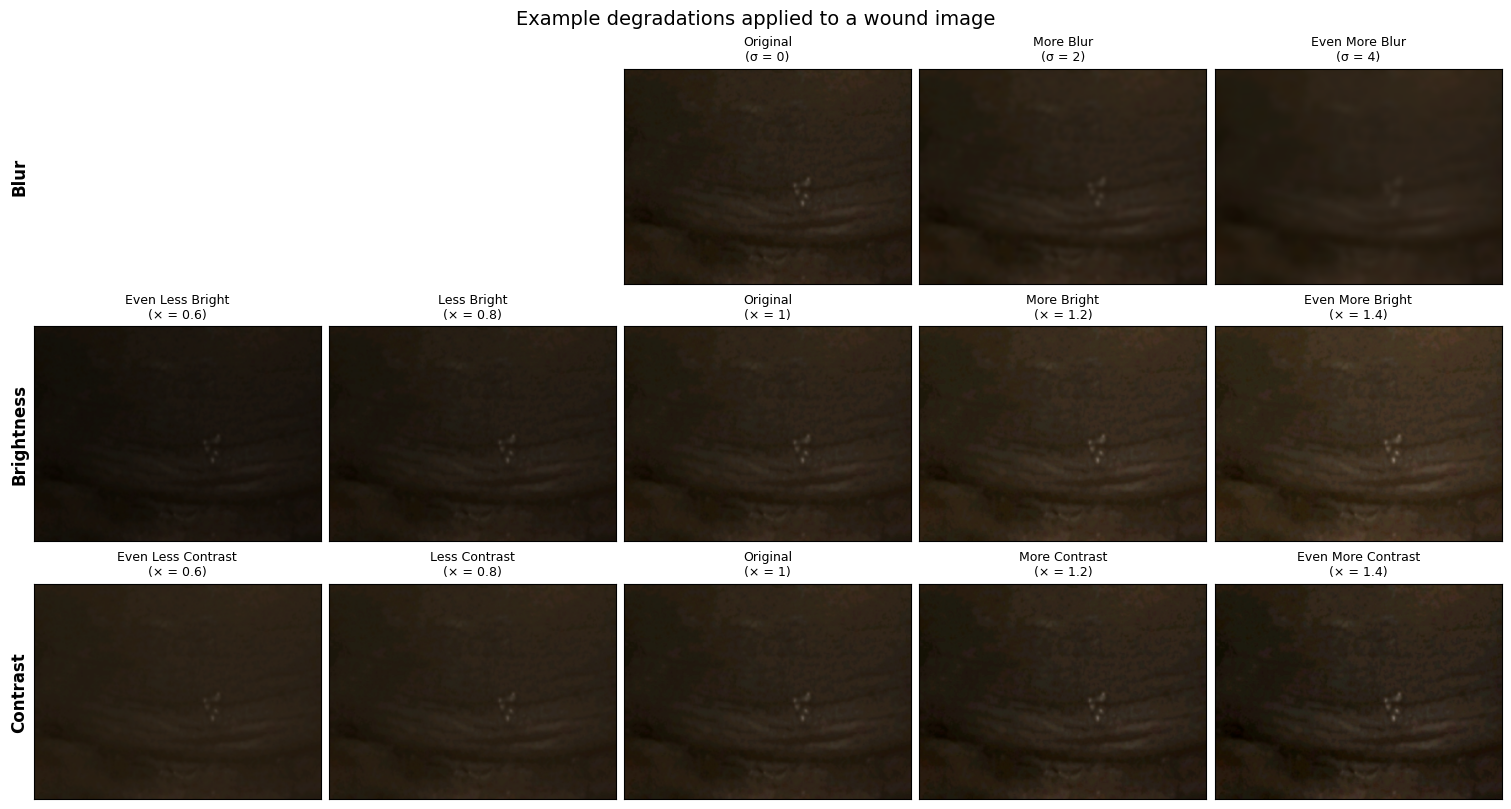

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import os
import re
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Degradation functions
# ------------------------------------------------------------------
def apply_blur(img, sigma):
    if sigma <= 0:
        return img.copy()
    return cv2.GaussianBlur(img, (0, 0), sigmaX=float(sigma), sigmaY=float(sigma))

def apply_brightness(img, factor):
    return np.clip(np.rint(img.astype(np.float32) * float(factor)), 0, 255).astype(np.uint8)

def apply_contrast(img, factor):
    """Pivot at the image's own per-channel mean, not 128."""
    f = img.astype(np.float32)
    pivot = f.mean(axis=(0, 1), keepdims=True)
    return np.clip(np.rint((f - pivot) * float(factor) + pivot), 0, 255).astype(np.uint8)


# ------------------------------------------------------------------
# Load the ORIGINAL rectangular image instead of the processed
# 224 × 224 square image
# ------------------------------------------------------------------
processed_example_path = all_paths[int(np.argmax(all_labels))]

# Obtain the participant ID from the processed filename
record_id = int(
    os.path.splitext(os.path.basename(processed_example_path))[0]
)

raw_images = imgs_under(RAW_DIR)

pod_encoded = any(
    re.search(r'visible-\d+-p1[01]-', os.path.basename(path))
    for path in raw_images
)

raw_example_path = Preprocessor.pick_for_record(
    raw_images,
    record_id,
    pod_encoded
)

assert raw_example_path is not None, (
    f"Could not locate the original image for record {record_id}."
)

img = cv2.imread(raw_example_path)

assert img is not None, (
    f"Could not read the original image: {raw_example_path}"
)


# ------------------------------------------------------------------
# Crop the image to a 4:3 rectangle without stretching it
# ------------------------------------------------------------------
def center_crop_to_ratio(image, target_ratio=4 / 3):
    """
    Center-crop an image to the requested width-to-height ratio.
    This changes the crop, but does not stretch or distort the wound.
    """
    height, width = image.shape[:2]
    current_ratio = width / height

    if current_ratio > target_ratio:
        # Image is too wide: crop the left and right edges
        new_width = int(height * target_ratio)
        x_start = (width - new_width) // 2
        image = image[:, x_start:x_start + new_width]

    elif current_ratio < target_ratio:
        # Image is too tall: crop the top and bottom edges
        new_height = int(width / target_ratio)
        y_start = (height - new_height) // 2
        image = image[y_start:y_start + new_height, :]

    return image


img = center_crop_to_ratio(img, target_ratio=4 / 3)

# Standardize the figure panels as rectangular 400 × 300 images
img = cv2.resize(
    img,
    (400, 300),
    interpolation=cv2.INTER_AREA
)


# ------------------------------------------------------------------
# Gradual example levels
#
# Brightness and contrast now move in increments of 0.1:
# 0.8, 0.9, 1.0, 1.1, 1.2
#
# Blur also increases gradually:
# 0, 1, 2
# ------------------------------------------------------------------
GRID = {
    'Blur': [
        None,
        None,
        ('Original',       ('blur', 0.0)),
        ('More Blur',      ('blur', 2.0)),
        ('Even More Blur', ('blur', 4.0)),
    ],

    'Brightness': [
        ('Even Less Bright', ('brightness', 0.6)),
        ('Less Bright',      ('brightness', 0.8)),
        ('Original',         ('brightness', 1.0)),
        ('More Bright',      ('brightness', 1.2)),
        ('Even More Bright', ('brightness', 1.4)),
    ],

    'Contrast': [
        ('Even Less Contrast', ('contrast', 0.6)),
        ('Less Contrast',      ('contrast', 0.8)),
        ('Original',           ('contrast', 1.0)),
        ('More Contrast',      ('contrast', 1.2)),
        ('Even More Contrast', ('contrast', 1.4)),
    ],
}


OPERATIONS = {
    'blur': apply_blur,
    'brightness': apply_brightness,
    'contrast': apply_contrast
}

UNITS = {
    'blur': 'σ',
    'brightness': '×',
    'contrast': '×'
}


def make_blank_axis(ax, row_name=None):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(3 / 4)

    for spine in ax.spines.values():
        spine.set_visible(False)

    if row_name is not None:
        ax.set_ylabel(
            row_name,
            fontsize=12,
            fontweight='bold'
        )


# ------------------------------------------------------------------
# Create figure
# ------------------------------------------------------------------
nrows = len(GRID)
ncols = 5

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 8),
    constrained_layout=True
)

for row_index, (row_name, cells) in enumerate(GRID.items()):
    for column_index, cell in enumerate(cells):

        ax = axes[row_index, column_index]
        ax.set_box_aspect(3 / 4)

        if cell is None:
            make_blank_axis(
                ax,
                row_name=row_name if column_index == 0 else None
            )
            continue

        title, (operation_name, value) = cell

        degraded_image = OPERATIONS[operation_name](img, value)

        ax.imshow(
            cv2.cvtColor(degraded_image, cv2.COLOR_BGR2RGB)
        )

        ax.set_title(
            f'{title}\n({UNITS[operation_name]} = {value:g})',
            fontsize=9
        )

        ax.set_xticks([])
        ax.set_yticks([])

        if column_index == 0:
            ax.set_ylabel(
                row_name,
                fontsize=12,
                fontweight='bold'
            )


fig.suptitle(
    'Example degradations applied to a wound image',
    fontsize=14
)

os.makedirs('/content/pod11_final', exist_ok=True)

output_path = '/content/pod11_final/degradation_examples.png'

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

from google.colab import files
files.download(output_path)

Chosen candidates (label, index): [('infected', 4), ('non-infected', 422), ('non-infected', 151)]


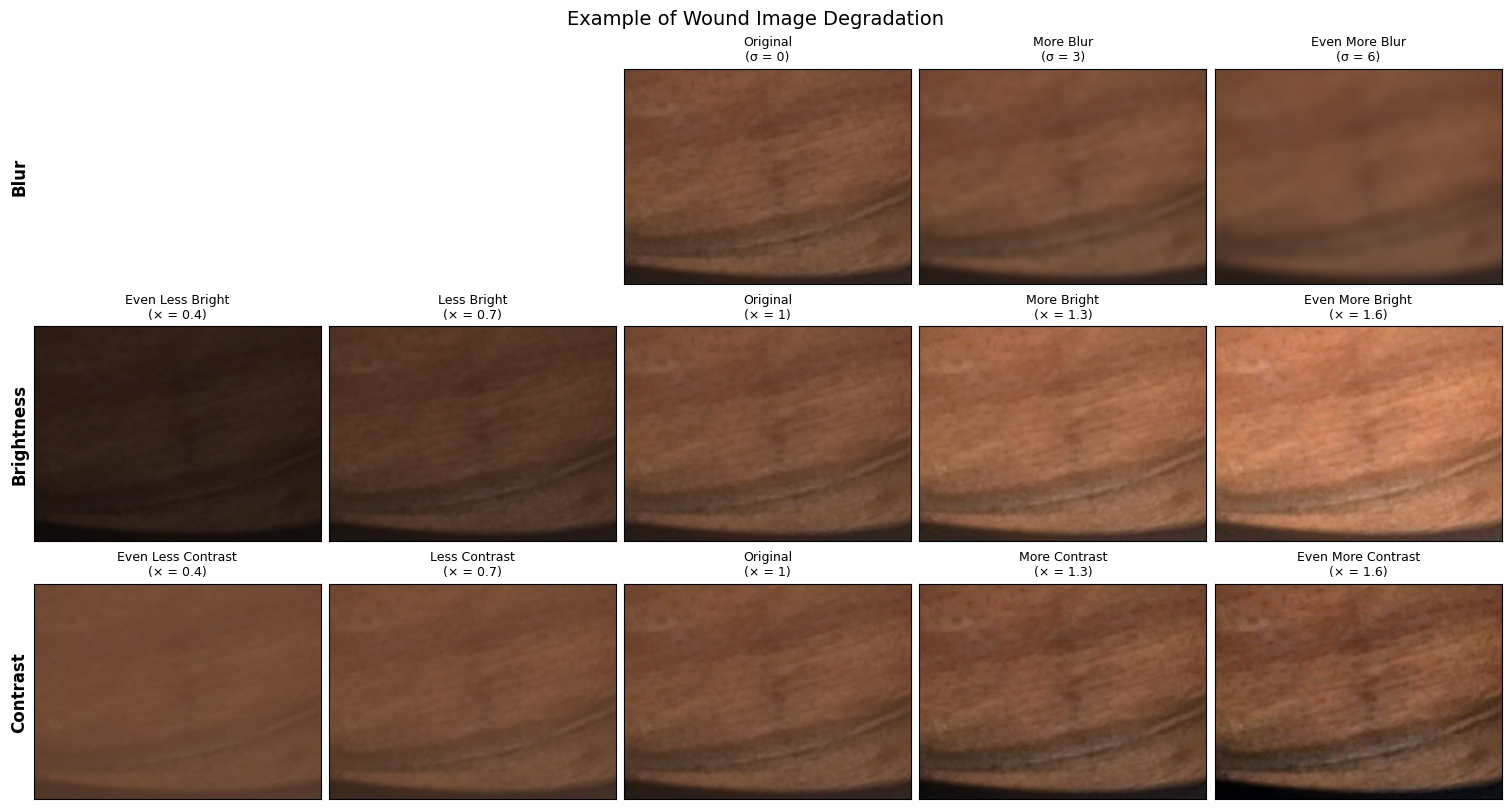

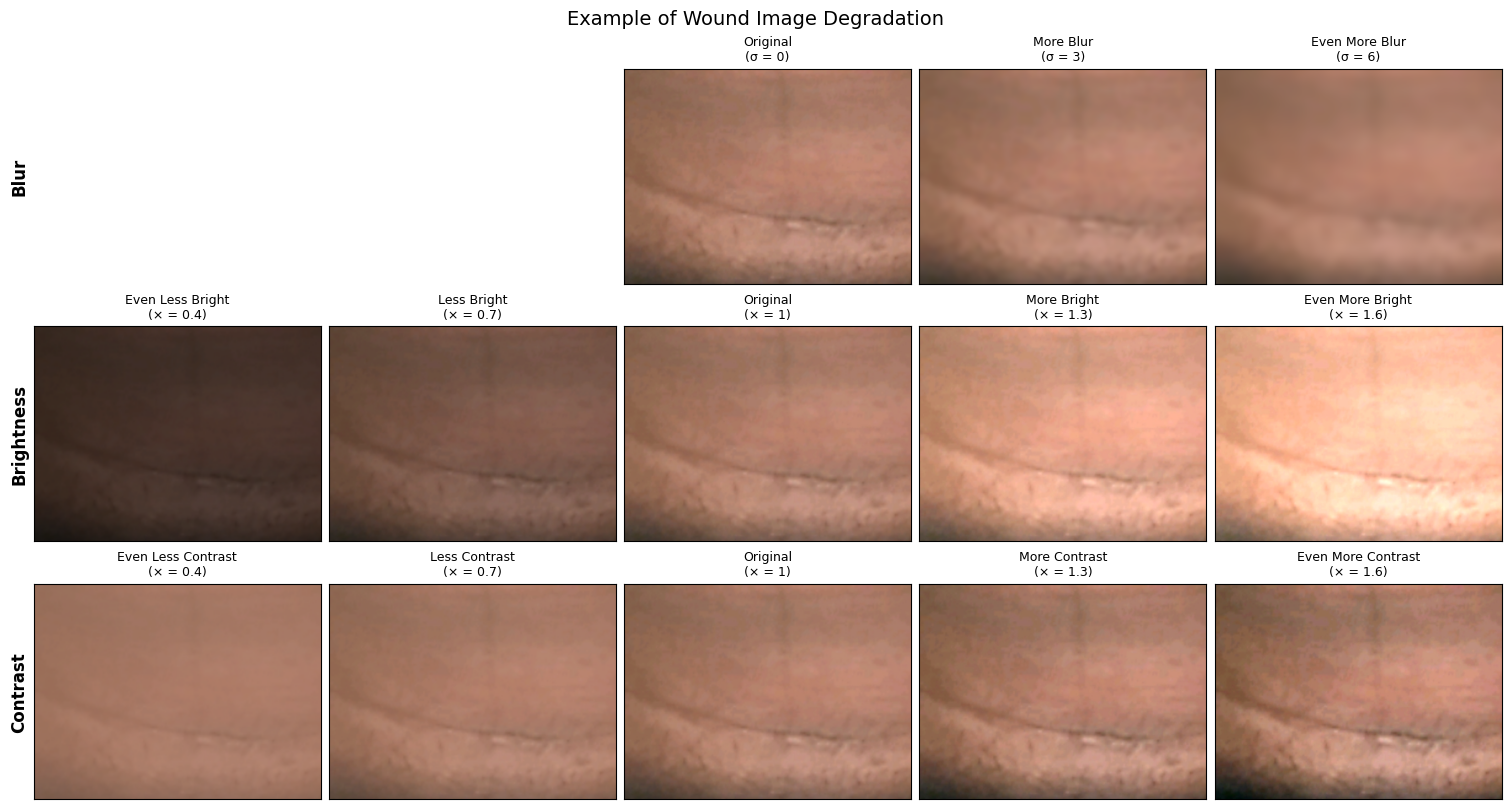

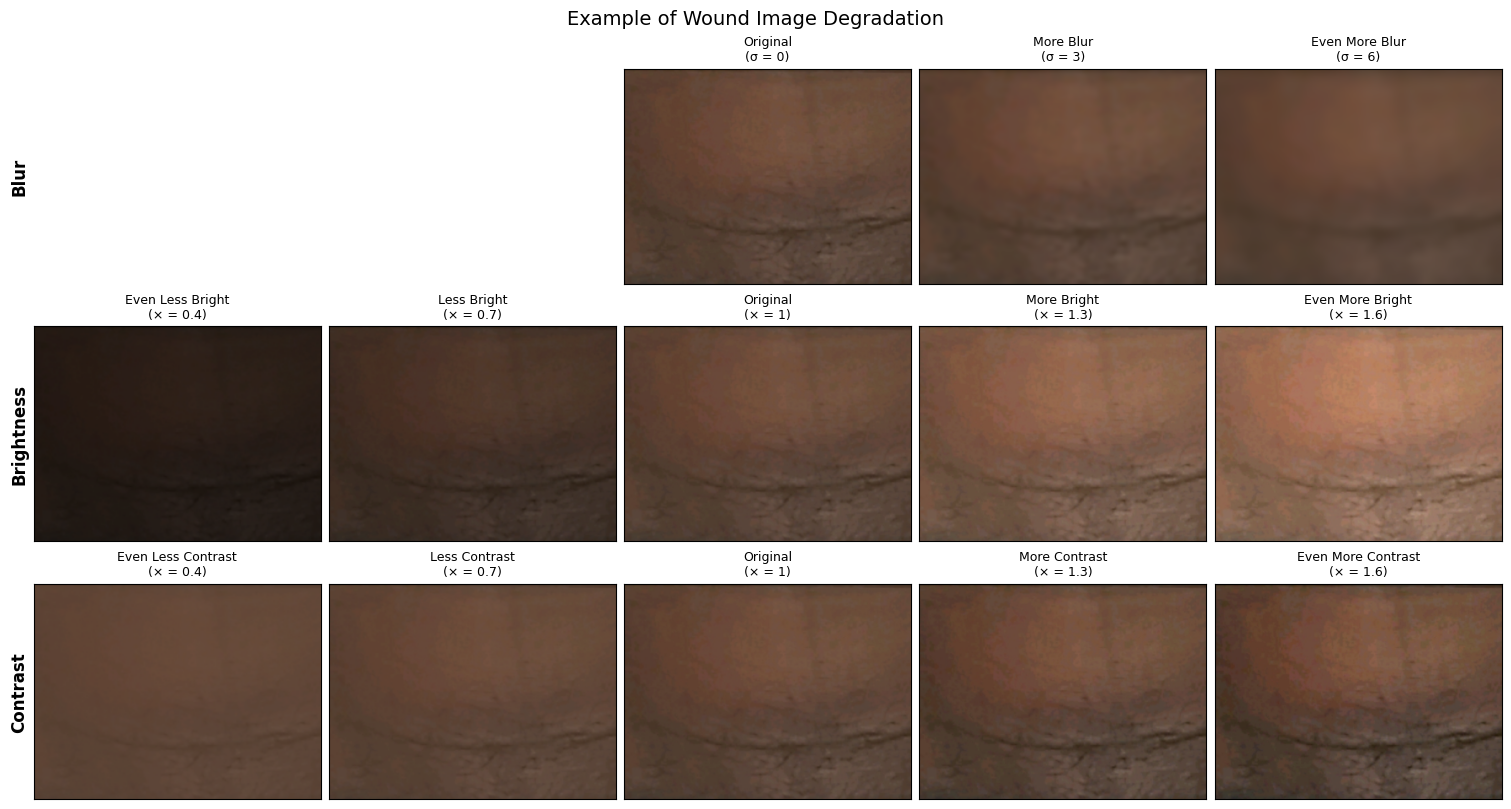

In [ ]:
import cv2, numpy as np, os, re
import matplotlib.pyplot as plt

# ---- same degradation ops as the analysis ----
def apply_blur(img, sigma):
    if sigma <= 0:
        return img.copy()
    return cv2.GaussianBlur(img, (0, 0), sigmaX=float(sigma), sigmaY=float(sigma))

def apply_brightness(img, factor):
    return np.clip(np.rint(img.astype(np.float32) * float(factor)), 0, 255).astype(np.uint8)

def apply_contrast(img, factor):
    """Pivot at the image's own per-channel mean, not 128."""
    f = img.astype(np.float32)
    pivot = f.mean(axis=(0, 1), keepdims=True)
    return np.clip(np.rint((f - pivot) * float(factor) + pivot), 0, 255).astype(np.uint8)

OP   = {'blur': apply_blur, 'brightness': apply_brightness, 'contrast': apply_contrast}
UNIT = {'blur': 'σ', 'brightness': '×', 'contrast': '×'}

GRID = {
    'Blur': [None, None,
        ('Original', ('blur', 0.0)), ('More Blur', ('blur', 3.0)), ('Even More Blur', ('blur', 6.0))],
    'Brightness': [
        ('Even Less Bright', ('brightness', 0.4)), ('Less Bright', ('brightness', 0.7)),
        ('Original', ('brightness', 1.0)), ('More Bright', ('brightness', 1.3)), ('Even More Bright', ('brightness', 1.6))],
    'Contrast': [
        ('Even Less Contrast', ('contrast', 0.4)), ('Less Contrast', ('contrast', 0.7)),
        ('Original', ('contrast', 1.0)), ('More Contrast', ('contrast', 1.3)), ('Even More Contrast', ('contrast', 1.6))],
}

def _blank(ax):
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_box_aspect(3 / 4)
    for s in ax.spines.values(): s.set_visible(False)

# ---- calmness score (bright but not vivid/bloody) — on the PROCESSED image, same as before ----
def calm_score(idx):
    im = cv2.imread(all_paths[idx])
    if im is None: return -1e9
    hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
    return im.mean() - 0.8 * hsv[:, :, 1].mean()
def calmest(pool, k):
    return [int(i) for i in sorted(pool, key=calm_score, reverse=True)[:k]]

inf_pool   = np.where(all_labels == 1)[0]
clean_pool = np.where(all_labels == 0)[0]

CANDIDATES = [
    ('infected',     calmest(inf_pool,   2)[1]),
    ('non-infected', calmest(clean_pool, 2)[0]),
    ('non-infected', calmest(clean_pool, 3)[2]),
]
print("Chosen candidates (label, index):", CANDIDATES)

# ---- map a processed index -> its RAW rectangular image, crop 4:3, standardize ----
raw_images = imgs_under(RAW_DIR)
pod_encoded = any(re.search(r'visible-\d+-p1[01]-', os.path.basename(p)) for p in raw_images)

def center_crop_to_ratio(image, target_ratio=4/3):
    h, w = image.shape[:2]
    r = w / h
    if r > target_ratio:
        nw = int(h * target_ratio); x0 = (w - nw) // 2
        image = image[:, x0:x0 + nw]
    elif r < target_ratio:
        nh = int(w / target_ratio); y0 = (h - nh) // 2
        image = image[y0:y0 + nh, :]
    return image

def load_rectangular_original(processed_idx):
    processed_path = all_paths[processed_idx]
    record_id = int(os.path.splitext(os.path.basename(processed_path))[0])
    raw_path = Preprocessor.pick_for_record(raw_images, record_id, pod_encoded)
    assert raw_path is not None, f"Could not locate the original image for record {record_id}."
    img = cv2.imread(raw_path)
    assert img is not None, f"Could not read the original image: {raw_path}"
    img = center_crop_to_ratio(img, 4/3)
    img = cv2.resize(img, (400, 300), interpolation=cv2.INTER_AREA)   # rectangular, no stretch
    return img, record_id

# ---- render the full grid for each candidate, using the rectangular original ----
def render_grid(example_idx, label, tag):
    img, record_id = load_rectangular_original(example_idx)
    nrows, ncols = len(GRID), 5
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), constrained_layout=True)
    for r, (rowname, cells) in enumerate(GRID.items()):
        for c, cell in enumerate(cells):
            ax = axes[r, c]
            ax.set_box_aspect(3 / 4)
            if cell is None:
                _blank(ax)
                if c == 0: ax.set_ylabel(rowname, fontsize=12, fontweight='bold')
                continue
            title, (opname, val) = cell
            d = OP[opname](img, val)
            ax.imshow(cv2.cvtColor(d, cv2.COLOR_BGR2RGB))
            ax.set_title(f'{title}\n({UNIT[opname]} = {val:g})', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0: ax.set_ylabel(rowname, fontsize=12, fontweight='bold')
    fig.suptitle('Example of Wound Image Degradation', fontsize=14)
    os.makedirs('/content/pod11_final', exist_ok=True)
    out = f'/content/pod11_final/degradation_examples_cand{tag}.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    return out

for n, (label, idx) in enumerate(CANDIDATES, start=1):
    render_grid(idx, label, n)

## 13. Degradation curves
3×3 grid (rows = degradation type, columns = metric). AUC panels show the 95% bootstrap band; every panel marks the clean/no-degradation point — at the left edge for blur (σ=0) but in the **interior** for brightness/contrast (factor=1.0), which degrade in both directions.


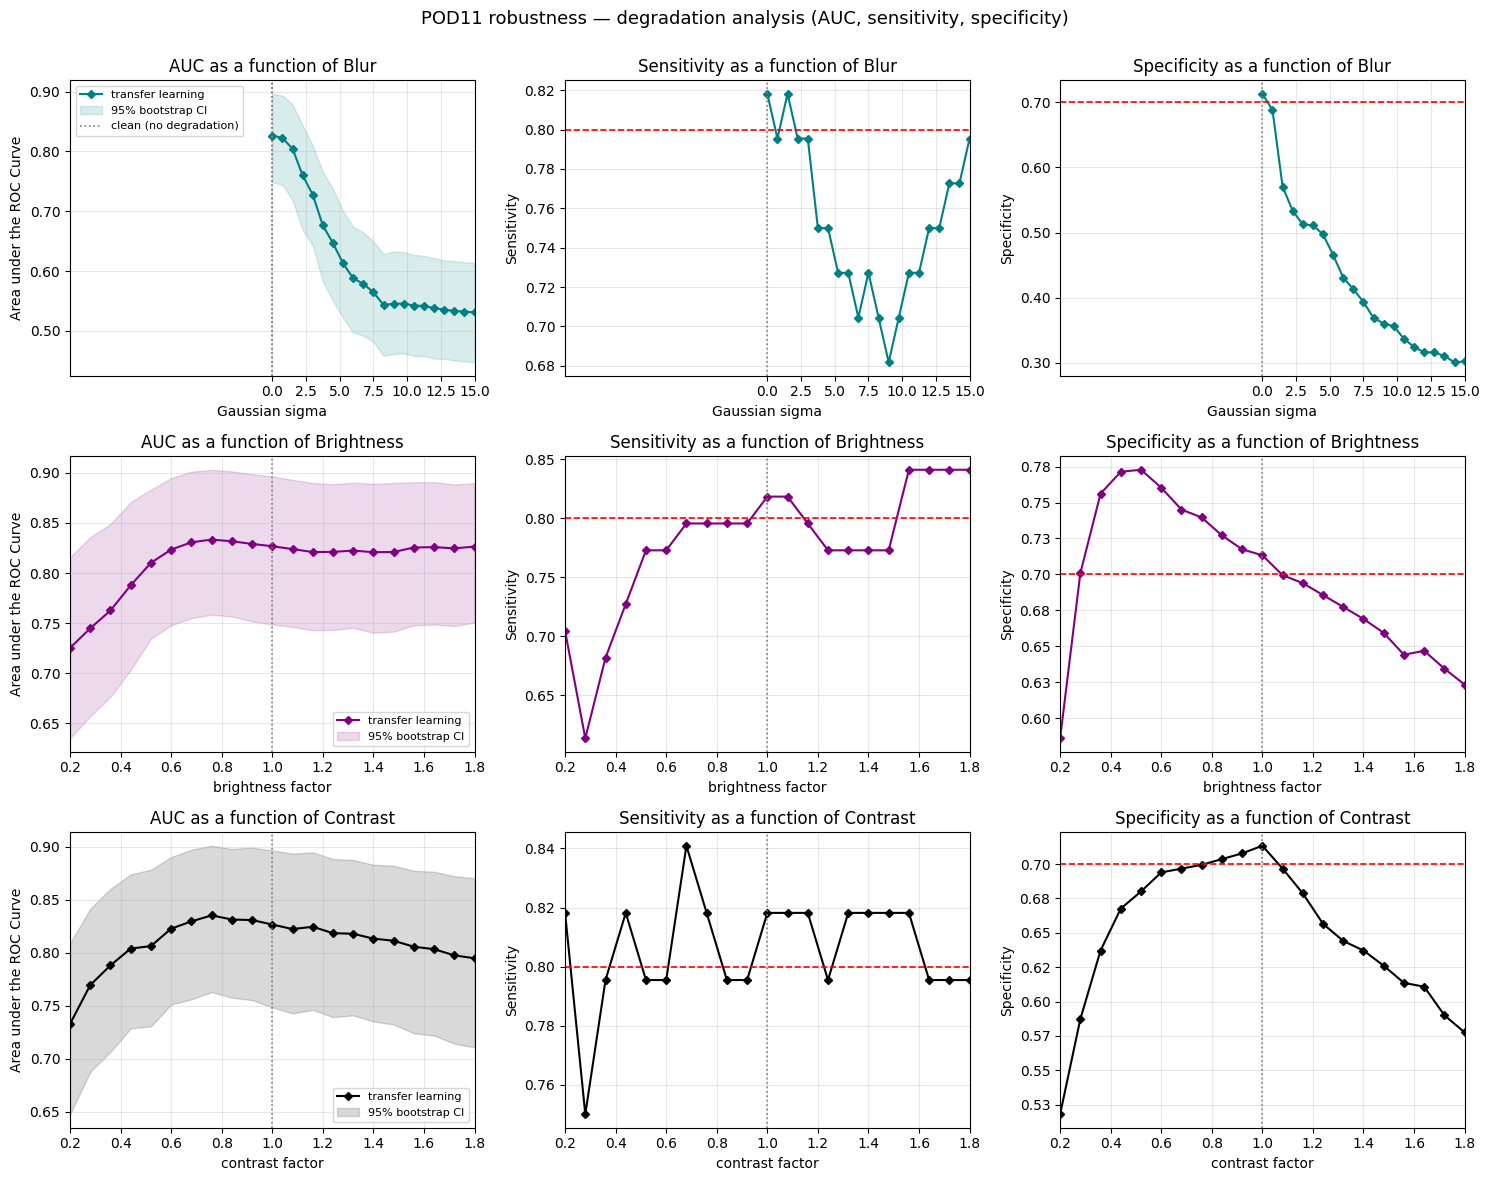

In [ ]:
# =============================================================================
# CELL 13 (corrected) — 3x3 grid with bootstrap CI bands on AUC and a marked
#                       clean reference at the correct point per degradation
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

metric_cols = [('auc',         'AUC',         'Area under the ROC Curve'),
               ('sensitivity', 'Sensitivity', 'Sensitivity'),
               ('specificity', 'Specificity', 'Specificity')]
benchmarks  = {'sensitivity': 0.80, 'specificity': 0.70}
deg_order   = ['blur', 'brightness', 'contrast']
xlabels     = {'blur': 'Gaussian sigma',
               'brightness': 'brightness factor',
               'contrast': 'contrast factor'}
colors      = {'blur': 'teal', 'brightness': 'purple', 'contrast': 'black'}
clean_point = {'blur': 0.0, 'brightness': 1.0, 'contrast': 1.0}

clean_base  = {'auc': base_auc, 'sensitivity': base_sens, 'specificity': base_spec}
XLIM        = {'blur': (-15.0, 15.0), 'brightness': (0.2, 1.8), 'contrast': (0.2, 1.8)}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for r, dname in enumerate(deg_order):
    sub = deg_df[deg_df.degradation == dname].sort_values('level')
    for c, (mkey, mshort, mlong) in enumerate(metric_cols):
        ax = axes[r, c]
        ax.plot(sub['level'], sub[mkey], marker='D', ms=4, color=colors[dname],
                label='transfer learning')

        # 95% bootstrap band on AUC only
        if mkey == 'auc':
            ax.fill_between(sub['level'], sub['auc_lo'], sub['auc_hi'],
                            color=colors[dname], alpha=0.15,
                            label='95% bootstrap CI')

        # Benchmark line from the caption.
        if mkey in benchmarks:
            ax.axhline(benchmarks[mkey], ls='--', color='red', lw=1.2)

        # Mark the clean (no-degradation) point. For brightness/contrast this is
        # in the interior at factor=1.0 — degradation increases in BOTH
        # directions away from it, which a single left-to-right reading misses.
        cp = clean_point[dname]
        ax.axvline(cp, ls=':', color='grey', lw=1.2)
        ax.set_xlim(*XLIM[dname])
        if dname == 'blur':                      # no ticks on the meaningless negative half
            ax.set_xticks(np.arange(0, 15.1, 2.5))
        if r == 0 and c == 0:
            ax.axvline(cp, ls=':', color='grey', lw=1.2, label='clean (no degradation)')


        ax.set_title(f'{mshort} as a function of {dname.capitalize()}')
        ax.set_xlabel(xlabels[dname]); ax.set_ylabel(mlong)
        # Consistent manuscript tick formatting
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.grid(alpha=0.3)
        if mkey == 'auc':
            ax.legend(fontsize=8)

        row = sub[np.isclose(sub['level'], cp)]
        assert len(row) == 1, f"{dname}: clean level {cp} missing from grid"
        assert np.isclose(row[mkey].iloc[0], clean_base[mkey]), \
            f"{dname}/{mkey}: level {cp} = {row[mkey].iloc[0]:.4f} != baseline {clean_base[mkey]:.4f}"

plt.suptitle('POD11 robustness — degradation analysis (AUC, sensitivity, specificity)',
           fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98])
os.makedirs('/content/pod11_final', exist_ok=True)
plt.savefig('/content/pod11_final/degradation_grid_3x3.png', dpi=300)
plt.savefig('/content/pod11_final/figure3_degradation_grid.pdf', bbox_inches='tight')
plt.show()


In [ ]:
import cv2, numpy as np, os

def apply_blur(img, sigma):
    if sigma <= 0:
        return img.copy()
    return cv2.GaussianBlur(img, (0, 0), sigmaX=float(sigma), sigmaY=float(sigma))

def apply_brightness(img, factor):
    return np.clip(np.rint(img.astype(np.float32) * float(factor)), 0, 255).astype(np.uint8)

def apply_contrast(img, factor):
    """Pivot at the image's own per-channel mean, not 128."""
    f = img.astype(np.float32)
    pivot = f.mean(axis=(0, 1), keepdims=True)
    return np.clip(np.rint((f - pivot) * float(factor) + pivot), 0, 255).astype(np.uint8)

OP = {'blur': apply_blur, 'brightness': apply_brightness, 'contrast': apply_contrast}

# (row_type, [(label, value), ...]) — same points as the grid figure
GRID = {
    'blur':       [('original', 0.0), ('more_blur', 7.5), ('even_more_blur', 15.0)],
    'brightness': [('even_less_bright', 0.2), ('less_bright', 0.6), ('original', 1.0),
                   ('more_bright', 1.4), ('even_more_bright', 1.8)],
    'contrast':   [('even_less_cont', 0.2), ('less_cont', 0.6), ('original', 1.0),
                   ('more_cont', 1.4), ('even_more_cont', 1.8)],
}

# Same example image the grid figure uses (first infected case)
example_path = all_paths[int(np.argmax(all_labels))]
img = cv2.imread(example_path)                    # BGR

OUT = '/content/pod11_final/degradation_cells'
os.makedirs(OUT, exist_ok=True)

saved = []
for row_type, cells in GRID.items():
    op = OP[row_type]
    for label, val in cells:
        d = op(img, val)
        path = os.path.join(OUT, f'{row_type}__{label}__{val:g}.png')
        cv2.imwrite(path, d)                       # cv2 writes BGR correctly
        saved.append(path)

print(f'Saved {len(saved)} images to {OUT}')
for p in saved:
    print('  ', os.path.basename(p))

# Optional: zip them and download in one go
import shutil
from google.colab import files
zip_base = '/content/pod11_final/degradation_cells'
shutil.make_archive(zip_base, 'zip', OUT)
files.download(zip_base + '.zip')

Saved 13 images to /content/pod11_final/degradation_cells
   blur__original__0.png
   blur__more_blur__7.5.png
   blur__even_more_blur__15.png
   brightness__even_less_bright__0.2.png
   brightness__less_bright__0.6.png
   brightness__original__1.png
   brightness__more_bright__1.4.png
   brightness__even_more_bright__1.8.png
   contrast__even_less_cont__0.2.png
   contrast__less_cont__0.6.png
   contrast__original__1.png
   contrast__more_cont__1.4.png
   contrast__even_more_cont__1.8.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import FormatStrFormatter

metric_cols = [('auc',         'AUC',         'Area under the ROC Curve'),
               ('sensitivity', 'Sensitivity', 'Sensitivity'),
               ('specificity', 'Specificity', 'Specificity')]
benchmarks  = {'sensitivity': 0.80, 'specificity': 0.70}
deg_order   = ['blur', 'brightness', 'contrast']
xlabels     = {'blur': 'Gaussian sigma',
               'brightness': 'brightness factor',
               'contrast': 'contrast factor'}
colors      = {'blur': 'teal', 'brightness': 'purple', 'contrast': 'black'}
clean_point = {'blur': 0.0, 'brightness': 1.0, 'contrast': 1.0}
clean_base  = {'auc': base_auc, 'sensitivity': base_sens, 'specificity': base_spec}
XLIM        = {'blur': (-15.0, 15.0), 'brightness': (0.2, 1.8), 'contrast': (0.2, 1.8)}

OUT = '/content/pod11_final/degradation_panels0.8'
os.makedirs(OUT, exist_ok=True)

saved = []
for dname in deg_order:
    sub = deg_df[deg_df.degradation == dname].sort_values('level')
    for mkey, mshort, mlong in metric_cols:
        fig, ax = plt.subplots(figsize=(6, 5))       # one panel per figure

        ax.plot(sub['level'], sub[mkey], marker='D', ms=4, color=colors[dname],
                label='transfer learning')

        if mkey == 'auc':                             # CI band on AUC only
            ax.fill_between(sub['level'], sub['auc_lo'], sub['auc_hi'],
                            color=colors[dname], alpha=0.15, label='95% bootstrap CI')

        if mkey in benchmarks:                        # red benchmark line
            ax.axhline(benchmarks[mkey], ls='--', color='red', lw=1.2)

        ax.axhline(clean_base[mkey], ls='-.', color='dimgrey', lw=1.0,
                   label='clean baseline value')

        cp = clean_point[dname]                       # clean reference line
        ax.axvline(cp, ls=':', color='grey', lw=1.2,
                   label='clean (no degradation)')
        ax.set_xlim(*XLIM[dname])
        if dname == 'blur':                           # negative sigma is meaningless
            ax.set_xticks(np.arange(0, 15.1, 2.5))

        ax.set_title(f'{mshort} as a function of {dname.capitalize()}')
        ax.set_xlabel(xlabels[dname]); ax.set_ylabel(mlong)
        # Consistent decimal formatting
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

        fig.tight_layout()
        fname = f'{dname}__{mkey}.png'
        path = os.path.join(OUT, fname)
        fig.savefig(path, dpi=300, bbox_inches='tight')
        plt.close(fig)                                # free memory, don't display 9 figs
        saved.append(path)

print(f'Saved {len(saved)} panels to {OUT}')
for p in saved:
    print('  ', os.path.basename(p))

# Zip and download all nine at once
import shutil
from google.colab import files
zip_base = '/content/pod11_final/degradation_panels'
shutil.make_archive(zip_base, 'zip', OUT)
files.download(zip_base + '.zip')

Saved 9 panels to /content/pod11_final/degradation_panels0.8
   blur__auc.png
   blur__sensitivity.png
   blur__specificity.png
   brightness__auc.png
   brightness__sensitivity.png
   brightness__specificity.png
   contrast__auc.png
   contrast__sensitivity.png
   contrast__specificity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Download results

In [ ]:
# =============================================================================
# Section 15 — Freeze this run: metrics + predictions + figures
# Writes a readable summary, mirrors everything to Drive (so a re-run RELOADS
# instead of retraining), then downloads one small zip to your computer.
# =============================================================================
import os, json, shutil, numpy as np, pandas as pd

WORK_DIR  = '/content/pod11_final'      # figures + result CSVs land here
DRIVE_DIR = OOF_DIR                     # '/content/drive/MyDrive/pod11_final'
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DRIVE_DIR, exist_ok=True)

summary = {
    'pooled_oof_auc':       float(pooled_auc),
    'mean_fold_auc':        float(mean_auc),
    'frozen_threshold':     float(FIXED_THRESHOLD),
    'baseline_auc':         float(base_auc),
    'baseline_sensitivity': float(base_sens),
    'baseline_specificity': float(base_spec),
    'n_images':             int(len(all_labels)),
    'n_infected':           int(np.sum(all_labels)),
}
pd.DataFrame([summary]).to_csv(os.path.join(WORK_DIR, 'run_summary.csv'), index=False)
with open(os.path.join(WORK_DIR, 'run_summary.json'), 'w') as fh:
    json.dump({**summary, 'fold_aucs': [float(a) for a in fold_aucs]}, fh, indent=2)
print(json.dumps(summary, indent=2))

# Mirror the working files into Drive so nothing depends on this runtime staying alive.
for f in os.listdir(WORK_DIR):
    src = os.path.join(WORK_DIR, f)
    if os.path.isfile(src):
        shutil.copy(src, os.path.join(DRIVE_DIR, f))
print(f"\nMirrored {WORK_DIR} -> {DRIVE_DIR}")

# Stage a download WITHOUT the model weights (.pt files are ~94 MB each).
STAGE = '/content/_bundle'
shutil.rmtree(STAGE, ignore_errors=True)
os.makedirs(STAGE)
for d in (DRIVE_DIR, WORK_DIR):
    for f in os.listdir(d):
        src = os.path.join(d, f)
        if os.path.isfile(src) and not f.endswith('.pt'):
            shutil.copy(src, os.path.join(STAGE, f))
print('In the download:', sorted(os.listdir(STAGE)))

shutil.make_archive('/content/pod11_final_bundle', 'zip', STAGE)
from google.colab import files
files.download('/content/pod11_final_bundle.zip')

{
  "pooled_oof_auc": 0.8267438932258878,
  "mean_fold_auc": 0.8750837520938024,
  "frozen_threshold": 0.36615806818008423,
  "baseline_auc": 0.8267438932258878,
  "baseline_sensitivity": 0.8181818181818182,
  "baseline_specificity": 0.7132963988919667,
  "n_images": 766,
  "n_infected": 44
}

Mirrored /content/pod11_final -> /content/drive/MyDrive/pod11_final
In the download: ['degradation_cells.zip', 'degradation_examples.png', 'degradation_examples_cand1.png', 'degradation_examples_cand2.png', 'degradation_examples_cand3.png', 'degradation_grid_3x3.png', 'degradation_panels.zip', 'degradation_results.csv', 'figure3_degradation_grid.pdf', 'fold_aucs.npy', 'oof_clean.npy', 'oof_deg.npz', 'pod11_roc_reproduction.png', 'run_summary.csv', 'run_summary.json']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>